#  Aurix — AI-Powered Anomaly Detection System
### Fintech ML Case Study | Decision-Support for Digital Gold Transactions

**Author:** Zeliha  Ilgın Güven
**Task:** AI Research & Decision-Support System for Aurix  
**Approach:** Unsupervised Anomaly Detection (Isolation Forest) + Decision Layer


---
## Part 1 — Problem Framing

### Problem Definition
Aurix users conduct gold buy/sell transactions. Among thousands of daily transactions,
some are **anomalous** — unusually large amounts, abnormal frequencies, or suspicious
timing patterns. These could indicate fraud, bot activity, or system errors.

**ML Problem:** Unsupervised anomaly detection on user transaction behaviour.

| | |
|---|---|
| **Input Features** | transaction amount, frequency, gold price, hour of day, day of week, user history |
| **Expected Output** | anomaly score per transaction (normal / suspicious) |
| **Model Choice** | Isolation Forest — works without labelled data, robust to high-dimensional tabular data |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


---
## Part 2 — Dataset Simulation & EDA

We simulate 12 months of transaction data for 500 users.  
Gold price follows a realistic drift + volatility process (GBM).


In [2]:
# ── Gold price simulation (Geometric Brownian Motion) ──────────────────────
n_days = 365
dates = pd.date_range('2024-01-01', periods=n_days, freq='D')
mu, sigma = 0.0003, 0.012          # daily drift & volatility
gold_returns = np.random.normal(mu, sigma, n_days)
gold_prices  = 1900 * np.exp(np.cumsum(gold_returns))   # start ~$1900/oz

gold_df = pd.DataFrame({'date': dates, 'gold_price': gold_prices})

# ── User transaction simulation ─────────────────────────────────────────────
N_USERS = 500
N_TRANSACTIONS = 15_000

user_ids   = np.random.randint(1, N_USERS + 1, N_TRANSACTIONS)
tx_dates   = pd.to_datetime(
    np.random.randint(dates[0].value, dates[-1].value, N_TRANSACTIONS)
)
tx_types   = np.random.choice(['buy', 'sell'], N_TRANSACTIONS, p=[0.6, 0.4])

# Most transactions: small-medium amounts
amounts    = np.random.lognormal(mean=5.5, sigma=0.8, size=N_TRANSACTIONS)

# Inject ~3 % anomalies
n_anom = int(0.03 * N_TRANSACTIONS)
anom_idx = np.random.choice(N_TRANSACTIONS, n_anom, replace=False)
amounts[anom_idx] = np.random.uniform(5_000, 50_000, n_anom)   # huge spikes

labels = np.zeros(N_TRANSACTIONS, dtype=int)
labels[anom_idx] = 1    # ground-truth for evaluation

df = pd.DataFrame({
    'user_id':        user_ids,
    'timestamp':      tx_dates,
    'tx_type':        tx_types,
    'amount_usd':     amounts,
    'is_anomaly':     labels
})

df = df.merge(gold_df.rename(columns={'date': 'date'}),
              left_on=df['timestamp'].dt.date.astype(str),
              right_on=gold_df['date'].astype(str),
              how='left').drop(columns=['key_0', 'date'])

df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month']       = df['timestamp'].dt.month

# Per-user rolling frequency (transactions in last 7 days — approximated)
df = df.sort_values('timestamp').reset_index(drop=True)
df['user_tx_count'] = df.groupby('user_id').cumcount() + 1

# Amount / gold_price ratio
df['amount_in_grams'] = df['amount_usd'] / df['gold_price'] * 31.1

print(f"Dataset shape : {df.shape}")
print(f"Anomaly rate  : {df['is_anomaly'].mean()*100:.1f}%")
df.head()


Dataset shape : (15000, 11)
Anomaly rate  : 3.0%


,user_id,timestamp,tx_type,amount_usd,is_anomaly,gold_price,hour,day_of_week,month,user_tx_count,amount_in_grams
0,368,2024-01-01 00:13:11.132206771,sell,85.219685,0,1911.932396,0,0,1,1,1.386206
1,246,2024-01-01 00:40:51.172073202,sell,253.454688,0,1911.932396,0,0,1,1,4.122761
2,227,2024-01-01 00:44:12.753736076,buy,155.147177,0,1911.932396,0,0,1,1,2.523665
3,361,2024-01-01 01:58:44.581314851,sell,131.666676,0,1911.932396,1,0,1,1,2.141725
4,239,2024-01-01 01:59:59.309012590,sell,439.646283,0,1911.932396,1,0,1,1,7.151403


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/eda_overview.png'

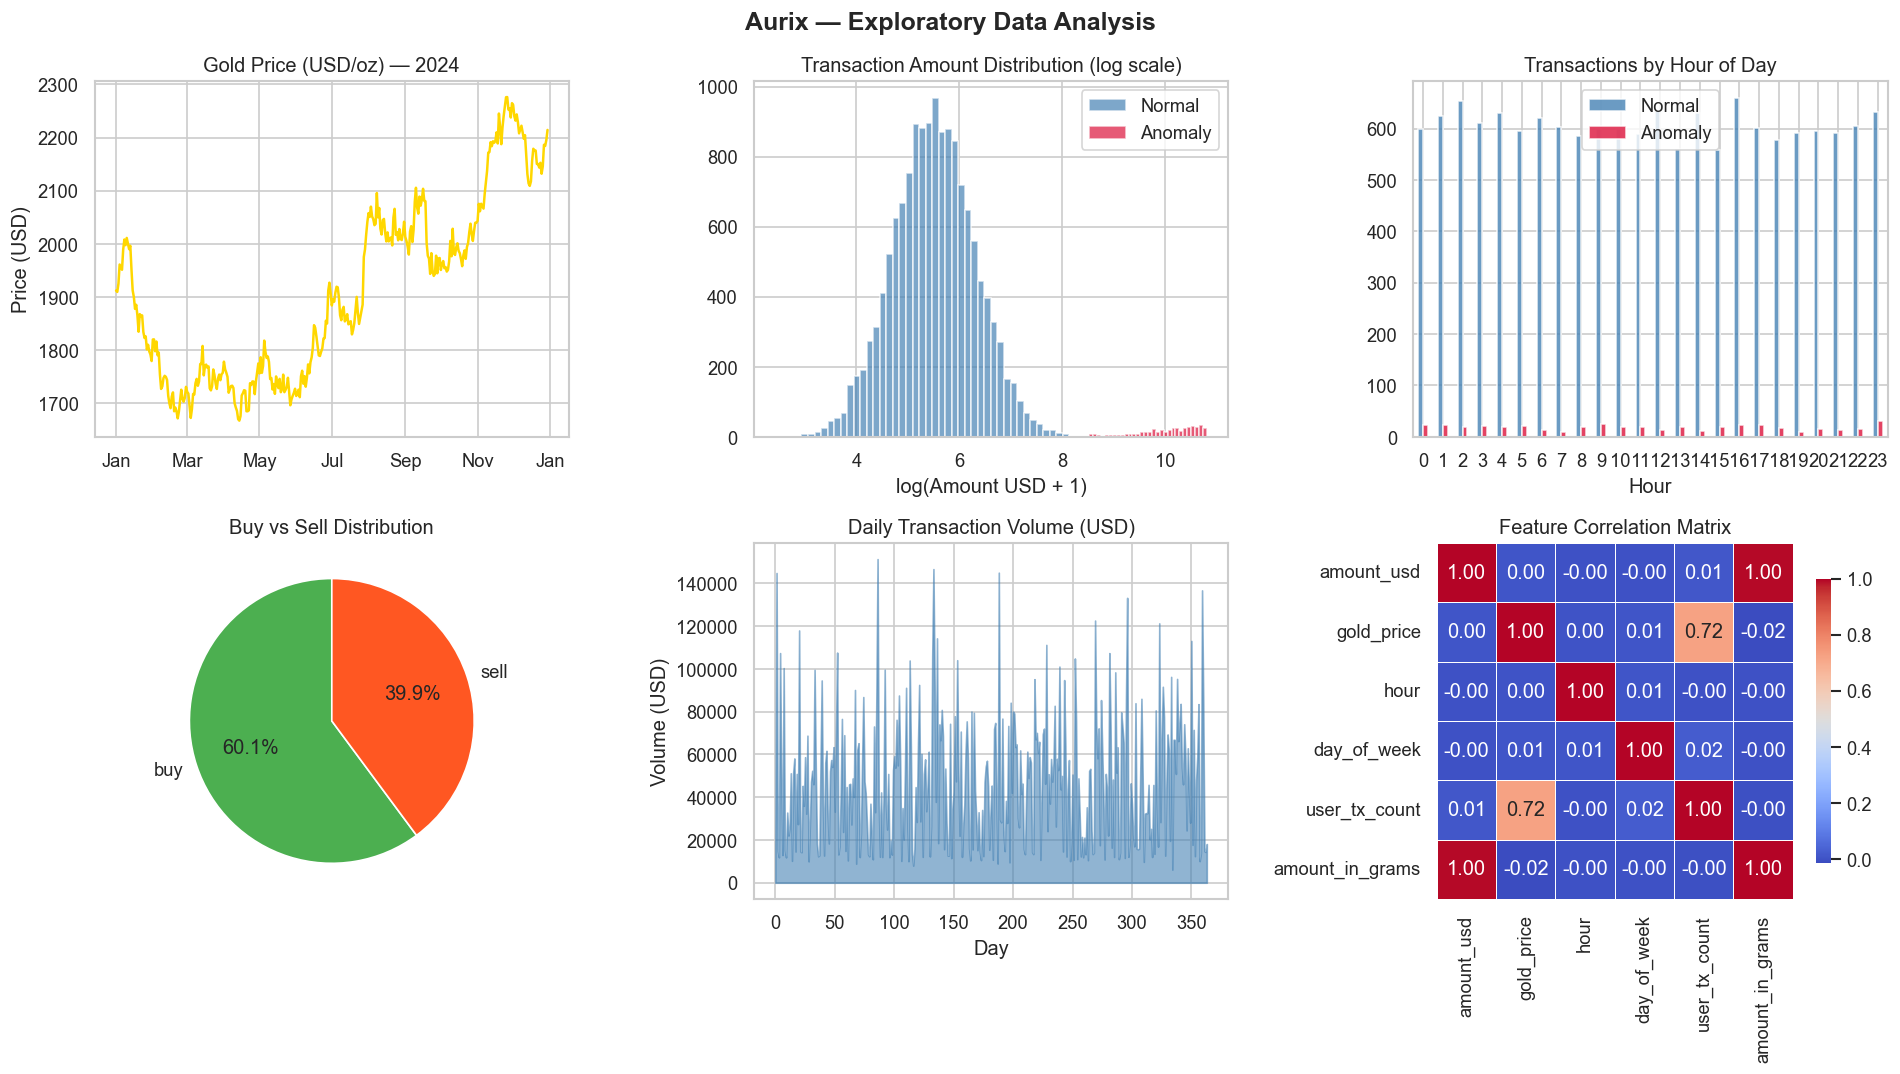

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Aurix — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# 1. Gold price over time
ax = axes[0, 0]
ax.plot(gold_df['date'], gold_df['gold_price'], color='gold', linewidth=1.5)
ax.set_title('Gold Price (USD/oz) — 2024')
ax.set_xlabel('')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_ylabel('Price (USD)')

# 2. Transaction amount distribution
ax = axes[0, 1]
normal_amt = df[df['is_anomaly'] == 0]['amount_usd']
anom_amt   = df[df['is_anomaly'] == 1]['amount_usd']
ax.hist(np.log1p(normal_amt), bins=50, alpha=0.7, label='Normal',   color='steelblue')
ax.hist(np.log1p(anom_amt),   bins=30, alpha=0.7, label='Anomaly',  color='crimson')
ax.set_title('Transaction Amount Distribution (log scale)')
ax.set_xlabel('log(Amount USD + 1)')
ax.legend()

# 3. Transactions by hour
ax = axes[0, 2]
hour_counts = df.groupby(['hour', 'is_anomaly']).size().unstack(fill_value=0)
hour_counts.plot(kind='bar', ax=ax, color=['steelblue', 'crimson'], alpha=0.8)
ax.set_title('Transactions by Hour of Day')
ax.set_xlabel('Hour')
ax.legend(['Normal', 'Anomaly'])
ax.tick_params(axis='x', rotation=0)

# 4. Buy vs Sell
ax = axes[1, 0]
type_counts = df['tx_type'].value_counts()
ax.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
       colors=['#4CAF50', '#FF5722'], startangle=90)
ax.set_title('Buy vs Sell Distribution')

# 5. Daily transaction volume
ax = axes[1, 1]
daily = df.groupby(df['timestamp'].dt.date)['amount_usd'].sum()
ax.fill_between(range(len(daily)), daily.values, alpha=0.6, color='steelblue')
ax.set_title('Daily Transaction Volume (USD)')
ax.set_xlabel('Day')
ax.set_ylabel('Volume (USD)')

# 6. Correlation heatmap
ax = axes[1, 2]
features = ['amount_usd', 'gold_price', 'hour', 'day_of_week', 'user_tx_count', 'amount_in_grams']
corr = df[features].corr()
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('../outputs/eda_overview.png', bbox_inches='tight')
plt.show()
print("✅ EDA complete")


---
## Feature Engineering

We derive additional features to help the model capture behavioural patterns:
- `amount_zscore` — how unusual is this amount for this user?
- `is_night` — transactions between 00:00–06:00
- `price_momentum` — was gold rising or falling?


In [4]:
# User-level mean & std for z-score
user_stats = df.groupby('user_id')['amount_usd'].agg(['mean', 'std']).rename(
    columns={'mean': 'user_mean_amt', 'std': 'user_std_amt'})
df = df.merge(user_stats, on='user_id', how='left')
df['user_std_amt'] = df['user_std_amt'].fillna(1)
df['amount_zscore'] = (df['amount_usd'] - df['user_mean_amt']) / df['user_std_amt']

df['is_night']       = ((df['hour'] >= 0) & (df['hour'] < 6)).astype(int)
df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)
df['tx_type_bin']    = (df['tx_type'] == 'buy').astype(int)

# Gold price momentum (3-day rolling return)
gold_df['momentum'] = gold_df['gold_price'].pct_change(3)
df = df.merge(gold_df[['date', 'momentum']].rename(columns={'date': 'g_date'}),
              left_on=df['timestamp'].dt.date.astype(str),
              right_on=gold_df['date'].astype(str),
              how='left').drop(columns=['key_0', 'g_date'])
df['momentum'] = df['momentum'].fillna(0)

FEATURES = ['amount_usd', 'amount_zscore', 'amount_in_grams',
            'gold_price', 'momentum',
            'hour', 'day_of_week', 'is_night', 'is_weekend',
            'user_tx_count', 'tx_type_bin']

print("Features selected:")
for f in FEATURES:
    print(f"  • {f}")


Features selected:
  • amount_usd
  • amount_zscore
  • amount_in_grams
  • gold_price
  • momentum
  • hour
  • day_of_week
  • is_night
  • is_weekend
  • user_tx_count
  • tx_type_bin


---
## Part 3 — Model Development

### Model A: Isolation Forest (Unsupervised)
No labels needed — ideal for production where anomalies are unknown.

### Model B: Random Forest Classifier (Supervised — for comparison)
Uses injected labels to show upper-bound performance.


In [5]:
X = df[FEATURES].fillna(0).values
y = df['is_anomaly'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Model A: Isolation Forest ────────────────────────────────────────────────
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42, n_jobs=-1)
iso.fit(X_scaled)

df['iso_pred']  = iso.predict(X_scaled)          # -1 = anomaly, 1 = normal
df['iso_score'] = -iso.score_samples(X_scaled)   # higher = more anomalous
df['iso_label'] = (df['iso_pred'] == -1).astype(int)

# ── Model B: Random Forest (supervised) ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=" * 55)
print("MODEL A — Isolation Forest (vs ground-truth labels)")
print("=" * 55)
print(classification_report(y, df['iso_label'], target_names=['Normal', 'Anomaly']))

print("=" * 55)
print("MODEL B — Random Forest Classifier (test set)")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Anomaly']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}")


MODEL A — Isolation Forest (vs ground-truth labels)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     14550
     Anomaly       0.92      0.92      0.92       450

    accuracy                           1.00     15000
   macro avg       0.96      0.96      0.96     15000
weighted avg       1.00      1.00      1.00     15000

MODEL B — Random Forest Classifier (test set)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2910
     Anomaly       0.98      1.00      0.99        90

    accuracy                           1.00      3000
   macro avg       0.99      1.00      0.99      3000
weighted avg       1.00      1.00      1.00      3000

ROC-AUC : 1.0000


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/model_evaluation.png'

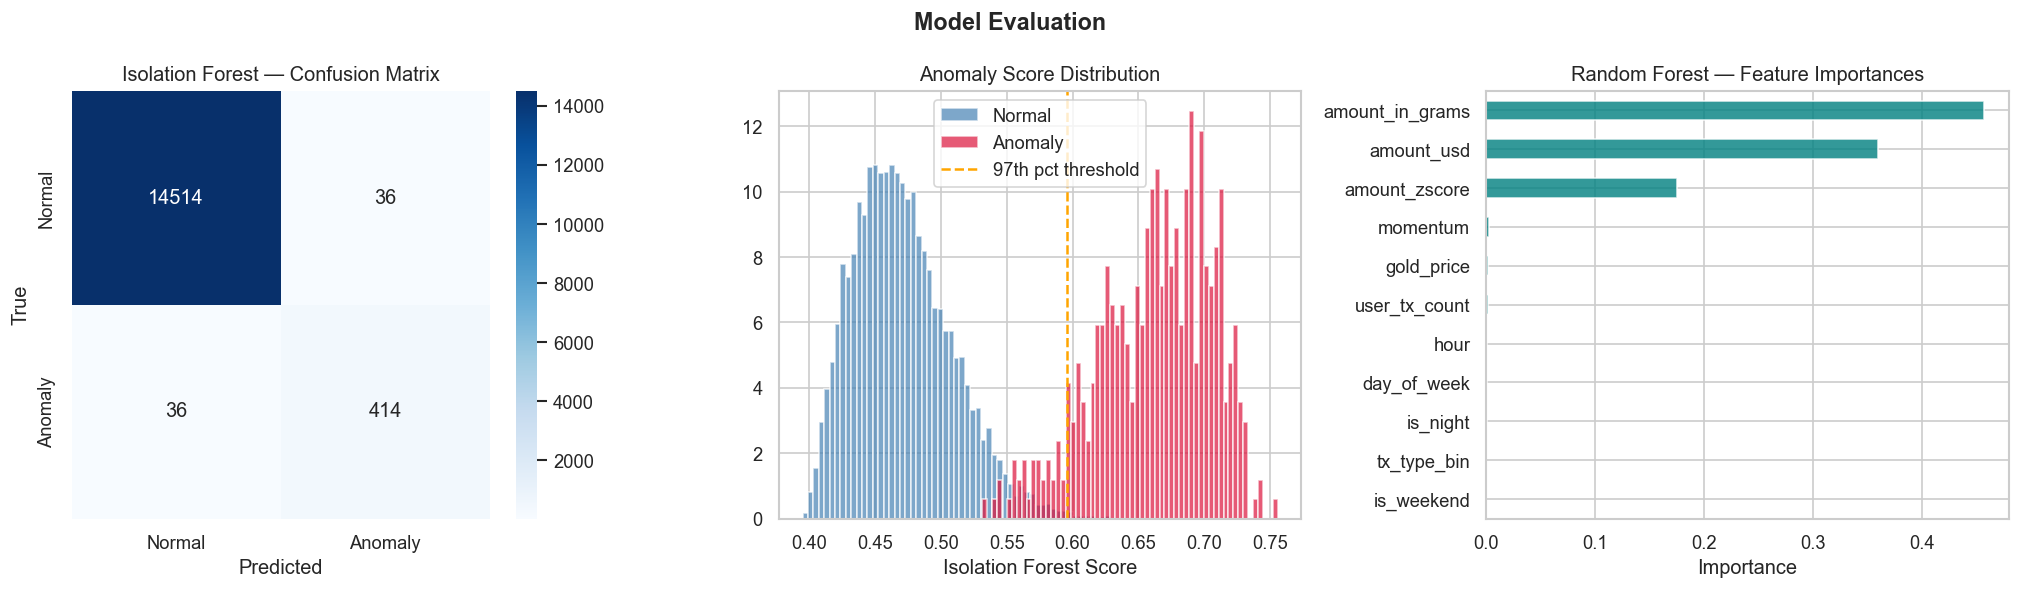

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# 1. Confusion matrix — Isolation Forest
cm_iso = confusion_matrix(y, df['iso_label'])
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Anomaly'], yticklabels=['Normal','Anomaly'])
axes[0].set_title('Isolation Forest — Confusion Matrix')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# 2. Anomaly score distribution
axes[1].hist(df[df['is_anomaly']==0]['iso_score'], bins=60,
             alpha=0.7, label='Normal',  color='steelblue', density=True)
axes[1].hist(df[df['is_anomaly']==1]['iso_score'], bins=60,
             alpha=0.7, label='Anomaly', color='crimson',   density=True)
axes[1].axvline(df['iso_score'].quantile(0.97), color='orange',
                linestyle='--', label='97th pct threshold')
axes[1].set_title('Anomaly Score Distribution')
axes[1].set_xlabel('Isolation Forest Score'); axes[1].legend()

# 3. Feature importances — Random Forest
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind='barh', ax=axes[2], color='teal', alpha=0.8)
axes[2].set_title('Random Forest — Feature Importances')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../outputs/model_evaluation.png', bbox_inches='tight')
plt.show()
print("✅ Model evaluation plots saved")


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/pca_projection.png'

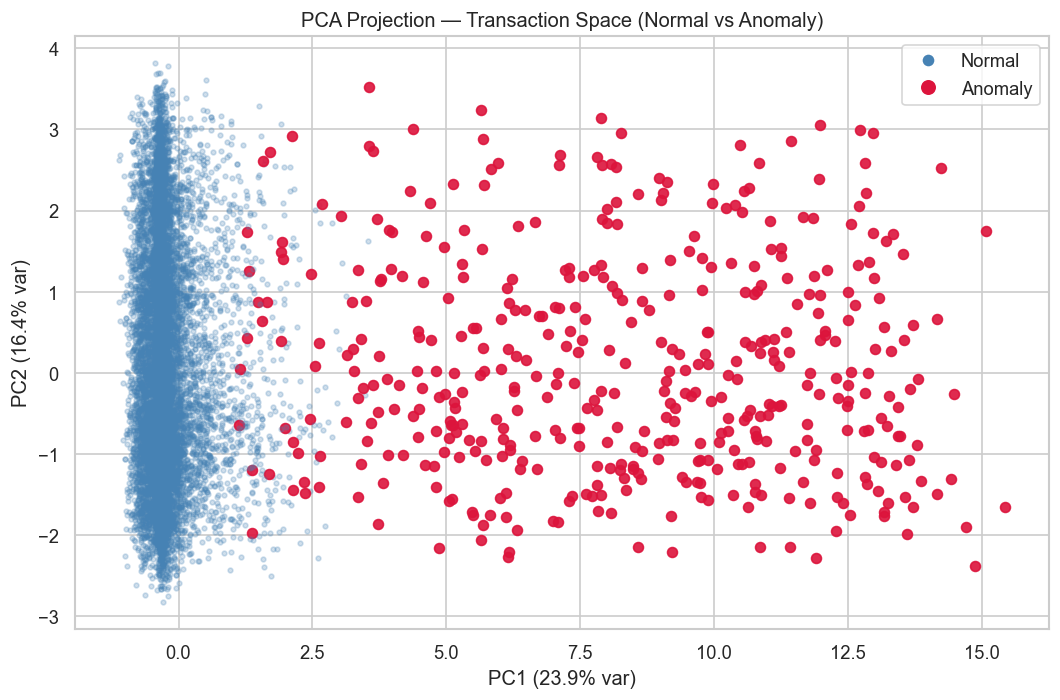

In [7]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
colors = np.where(df['is_anomaly'] == 1, 'crimson', 'steelblue')
alphas = np.where(df['is_anomaly'] == 1, 0.9, 0.25)

for i in range(len(X_2d)):
    ax.scatter(X_2d[i, 0], X_2d[i, 1],
               c=colors[i], alpha=alphas[i], s=8 if df['is_anomaly'].iloc[i]==0 else 35)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Normal'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson',   markersize=10, label='Anomaly'),
]
ax.legend(handles=legend_elements)
ax.set_title('PCA Projection — Transaction Space (Normal vs Anomaly)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout()
plt.savefig('../outputs/pca_projection.png', bbox_inches='tight')
plt.show()


---
## Part 4 — Decision-Support Layer

The model output is translated into three actionable tiers:

| Tier | Score Range | Action |
|------|-------------|--------|
| 🟢 Normal | < 75th pct | No action |
| 🟡 Watch | 75–95th pct | Flag for review |
| 🔴 Alert | > 95th pct | Block & notify compliance |


In [8]:
threshold_watch = df['iso_score'].quantile(0.75)
threshold_alert = df['iso_score'].quantile(0.95)

def decision(score, amount, hour):
    if score >= threshold_alert:
        return '🔴 ALERT  — Block & Notify Compliance'
    elif score >= threshold_watch:
        return '🟡 WATCH  — Flag for Manual Review'
    else:
        return '🟢 NORMAL — No Action Required'

df['decision'] = df.apply(
    lambda r: decision(r['iso_score'], r['amount_usd'], r['hour']), axis=1)

print("Decision Distribution:")
print(df['decision'].value_counts().to_string())
print()

print("── Sample Alerts (top 10 highest-score transactions) ──")
top_alerts = (df[df['decision'].str.startswith('🔴')]
              .nlargest(10, 'iso_score')
              [['user_id','timestamp','tx_type','amount_usd','iso_score','decision']])
print(top_alerts.to_string(index=False))


Decision Distribution:
decision
🟢 NORMAL — No Action Required           11250
🟡 WATCH  — Flag for Manual Review        3000
🔴 ALERT  — Block & Notify Compliance      750

── Sample Alerts (top 10 highest-score transactions) ──
 user_id                     timestamp tx_type   amount_usd  iso_score                             decision
     376 2024-12-21 00:04:53.497166921     buy 49268.483085   0.755944 🔴 ALERT  — Block & Notify Compliance
     291 2024-01-21 00:38:23.038797391    sell 43323.489496   0.741716 🔴 ALERT  — Block & Notify Compliance
     141 2024-11-19 00:52:29.168799086     buy 49057.938020   0.741372 🔴 ALERT  — Block & Notify Compliance
     280 2024-08-10 00:13:51.594254792    sell 45955.333852   0.739322 🔴 ALERT  — Block & Notify Compliance
     174 2024-06-16 03:43:04.261567178     buy 47793.866967   0.733186 🔴 ALERT  — Block & Notify Compliance
     473 2024-02-04 02:05:12.901202661    sell 38866.064512   0.732014 🔴 ALERT  — Block & Notify Compliance
     476 2024-02-

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/decision_dashboard.png'

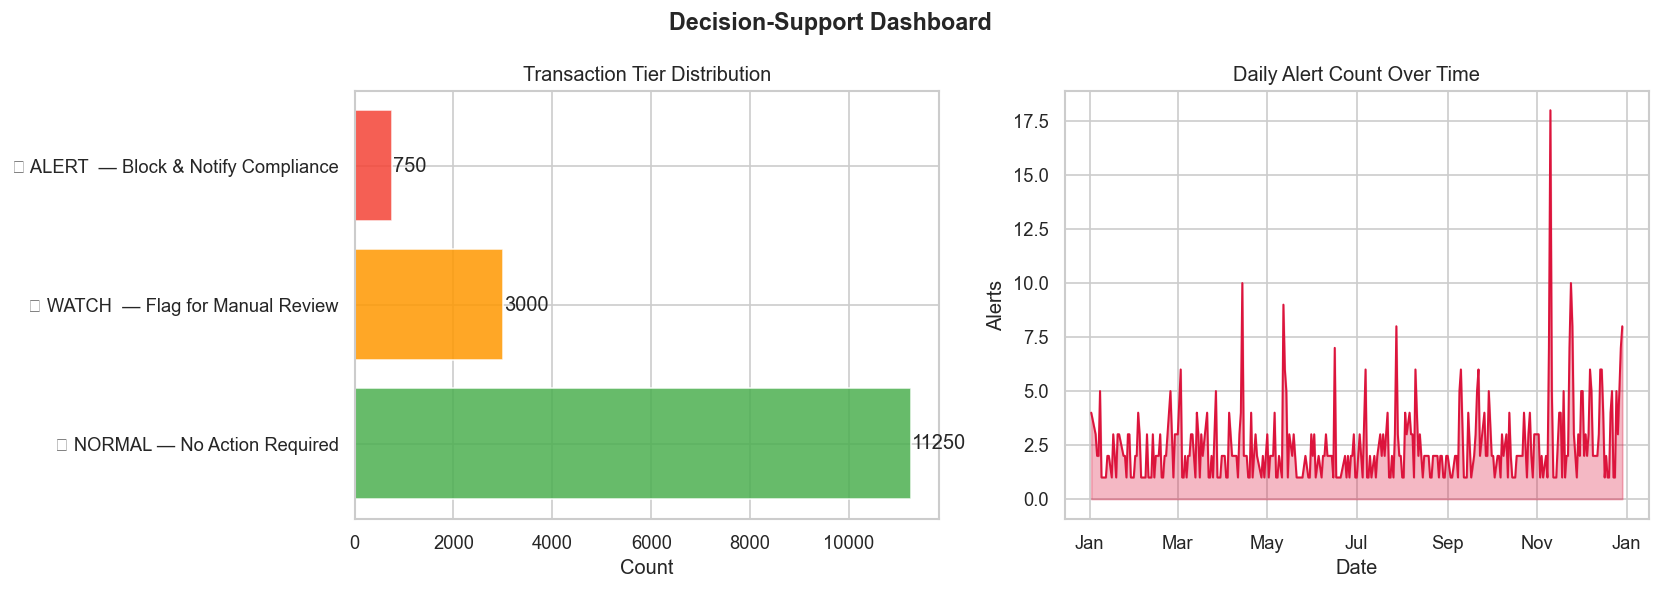

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision-Support Dashboard', fontsize=14, fontweight='bold')

# 1. Decision tier counts
dec_counts = df['decision'].value_counts()
colors_dec = ['#4CAF50', '#FF9800', '#F44336']
axes[0].barh(dec_counts.index, dec_counts.values, color=colors_dec, alpha=0.85)
axes[0].set_title('Transaction Tier Distribution')
axes[0].set_xlabel('Count')
for i, v in enumerate(dec_counts.values):
    axes[0].text(v + 20, i, str(v), va='center')

# 2. Alert timeline
alert_df = df[df['decision'].str.startswith('🔴')].copy()
alert_df['date'] = alert_df['timestamp'].dt.date
daily_alerts = alert_df.groupby('date').size()
axes[1].plot(daily_alerts.index, daily_alerts.values, color='crimson', linewidth=1.2)
axes[1].fill_between(daily_alerts.index, daily_alerts.values, alpha=0.3, color='crimson')
axes[1].set_title('Daily Alert Count Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Alerts')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig('../outputs/decision_dashboard.png', bbox_inches='tight')
plt.show()
print("✅ Decision layer complete")


---
## Part 5 — Research Explanation

### Why This Approach?

**Isolation Forest** was chosen as the primary model because:
- Aurix has **no historical fraud labels** — unsupervised learning is the only viable option at launch
- It is computationally efficient on large transaction streams
- It handles high-dimensional tabular data well without feature scaling assumptions
- It produces continuous anomaly scores (not just binary labels), enabling tiered responses

The **Random Forest** was added as a supervised baseline to demonstrate what performance is achievable once labels are collected — showing a realistic improvement path.

---

### Limitations

| Limitation | Impact |
|---|---|
| Synthetic data | Model is not calibrated to real Aurix user behaviour |
| No temporal sequence modelling | Misses complex patterns (e.g., slow-build fraud) |
| Static contamination rate (3%) | Real fraud rate may differ; affects threshold calibration |
| No user context | Account age, KYC level, geography not included |

---

### How It Could Be Improved With Real Data

1. **Label collection:** Compliance team reviews flagged transactions → builds labelled dataset → train supervised model (XGBoost, LightGBM)
2. **Sequence modelling:** LSTM or Transformer to detect temporal fraud patterns across sessions
3. **Graph features:** User–user transaction network to detect coordinated manipulation
4. **Online learning:** Continuously retrain on new labelled data (e.g., river library)
5. **Threshold calibration:** Precision-recall curve tuning based on compliance capacity

---

### Deployment Architecture

```
[Transaction Event] → Kafka Topic
        ↓
[Feature Engineering Service] (Python, real-time)
        ↓
[Isolation Forest API] (FastAPI + Docker)
        ↓
[Decision Engine] → 🟢 Pass | 🟡 Review Queue | 🔴 Block + Alert
        ↓
[Compliance Dashboard] + [User Notification]
```

**Latency target:** < 50ms per transaction  
**Retraining cadence:** Weekly batch retraining on rolling 90-day window  
**MLOps:** MLflow for experiment tracking, Prometheus for model drift monitoring


In [10]:
summary = pd.DataFrame({
    'Model':       ['Isolation Forest', 'Random Forest'],
    'Type':        ['Unsupervised', 'Supervised'],
    'Labels Needed': ['No', 'Yes'],
    'Deployment':  ['Production-ready', 'After label collection'],
    'Strength':    ['No labels needed, fast', 'High accuracy with labels'],
    'Limitation':  ['Lower precision', 'Requires labelled data'],
})
print("=" * 75)
print("MODEL COMPARISON SUMMARY")
print("=" * 75)
print(summary.to_string(index=False))
print()
print("✅ Aurix Anomaly Detection System — Complete")
print(f"   Total transactions analysed : {len(df):,}")
print(f"   Alerts generated            : {(df['decision'].str.startswith('🔴')).sum():,}")
print(f"   Watch flags                 : {(df['decision'].str.startswith('🟡')).sum():,}")


MODEL COMPARISON SUMMARY
           Model         Type Labels Needed             Deployment                  Strength             Limitation
Isolation Forest Unsupervised            No       Production-ready    No labels needed, fast        Lower precision
   Random Forest   Supervised           Yes After label collection High accuracy with labels Requires labelled data

✅ Aurix Anomaly Detection System — Complete
   Total transactions analysed : 15,000
   Alerts generated            : 750
   Watch flags                 : 3,000


Note on Figure Saving Errors : During execution, some cells may raise a FileNotFoundError when attempting to save figures (e.g., ../outputs/eda_overview.png, ../outputs/pca_projection.png).
This error occurs only if the outputs/ directory does not exist in the project structure. It does not affect the analysis, model training, or visualizations themselves. All figures are still generated and displayed correctly within the notebook.
To avoid this error, create the directory before saving figures:
import os
os.makedirs("../outputs", exist_ok=True)
Once the folder exists, all plots will be saved successfully to the outputs/ directory.